# Análise Exploratória dos dados

In [401]:
%%capture
!pip install xgboost catboost scikit-learn matplotlib seaborn pandas numpy

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import root_mean_squared_error
from catboost import CatBoostRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from ngboost import NGBRegressor
from xgboost import XGBRegressor
from collections import Counter
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.base import clone
from tqdm.notebook import tqdm
import os, shap
import seaborn as sns
import pandas as pd
import numpy as np

In [403]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [404]:
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto'
file_path = os.path.join(base_dir, 'BD_filerCalcario_versao_1.xlsx')
file = pd.ExcelFile(file_path)
print(file.sheet_names)
scaler = StandardScaler()
clusterer = HDBSCAN(min_cluster_size=2, min_samples=2)

['BD_ML_Resis', 'BD_ML_Slump_1', 'Dicionario_Variaveis']


In [405]:
df_slump = file.parse('BD_ML_Slump_1')
df_slump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Autores/ano                      126 non-null    object 
 1   ID_Mistura                       126 non-null    object 
 2   Tipo_Cimento_Classe              126 non-null    object 
 3   Massa_Esp_Cimento_g_cm3          110 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg      93 non-null     float64
 5   Massa_Esp_Filer_g_cm3            83 non-null     float64
 6   Finura_Filer_Blaine_m2_kg        65 non-null     float64
 7   Filer_D50_um                     72 non-null     float64
 8   Massa_Esp_Areia_g_cm3            78 non-null     float64
 9   Massa_Esp_Brita_g_cm3            78 non-null     float64
 10  D_Max                            92 non-null     float64
 11  Cimento_kg_m3                    126 non-null    float64
 12  Filer_Calcario_kg_m3  

In [406]:
autores = df_slump['Autores/ano'].unique()

for autor in autores:
    df_autor = df_slump[df_slump['Autores/ano'] == autor]
    print(f"{autor}, Número de amostras: {len(df_autor)} | {df_autor.shape[0]/len(df_slump)*100:.2f}%")

Dos Santos et al, 2024, Número de amostras: 5 | 3.97%
Guemmadi et al, 2009, Número de amostras: 23 | 18.25%
Meddah et al 2014, Número de amostras: 25 | 19.84%
A Morzouki 2016, Número de amostras: 7 | 5.56%
Feltrin 2018, Número de amostras: 12 | 9.52%
Gyu Don Moon 2017, Número de amostras: 8 | 6.35%
Hieu T Cam 2010, Número de amostras: 4 | 3.17%
Md Jahidul Islam 2025, Número de amostras: 5 | 3.97%
Mohammed e Al-Numan (2024), Número de amostras: 5 | 3.97%
Leeuwen et al, (2016), Número de amostras: 10 | 7.94%
Ramezanianpour et al. (2009), Número de amostras: 15 | 11.90%
Bonavetti et al. (2000)., Número de amostras: 2 | 1.59%
Tsivilis et al. (2003), Número de amostras: 5 | 3.97%


In [407]:
encoder_tipo = LabelEncoder()
encoder_substituicao = LabelEncoder()
encoder_empacotamento = LabelEncoder()
encoder_geometria = LabelEncoder()

In [408]:
df_slump['cod_classe'] = encoder_tipo.fit_transform(df_slump['Tipo_Cimento_Classe'])
df_slump['cod_classe'].value_counts()

,count
cod_classe,
6,28
5,25
9,17
0,15
14,10
2,6
12,5
11,4
1,4


In [409]:
df_slump['cod_substituicao'] = encoder_substituicao.fit_transform(df_slump['Metodo_Substituicao'])
df_slump['cod_substituicao'].value_counts()

,count
cod_substituicao,
0,110
1,16


In [410]:
df_slump['cod_empacotamento'] = encoder_empacotamento.fit_transform(df_slump['Metodo_Empacotamento'])
df_slump['cod_empacotamento'].value_counts()

,count
cod_empacotamento,
0,103
1,23


In [411]:
df_slump['cod_geometria'] = encoder_geometria.fit_transform(df_slump['Tipo_Molde_Geometria'])
df_slump['cod_geometria'].value_counts()

,count
cod_geometria,
0,46
3,40
1,30
2,10


/tmp/ipykernel_44435/3852430961.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


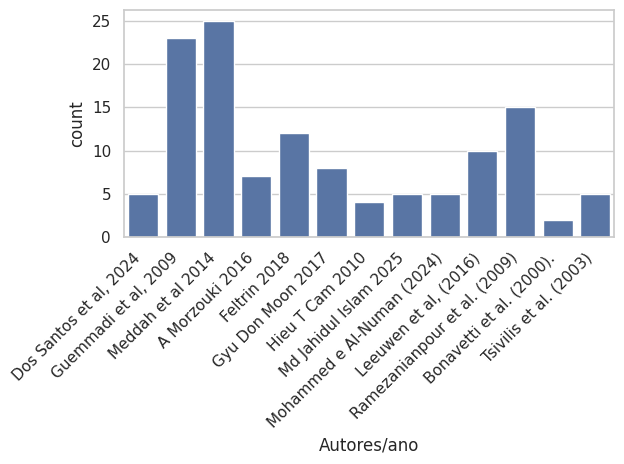

In [412]:
ax = sns.countplot(x='Autores/ano', data=df_slump)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

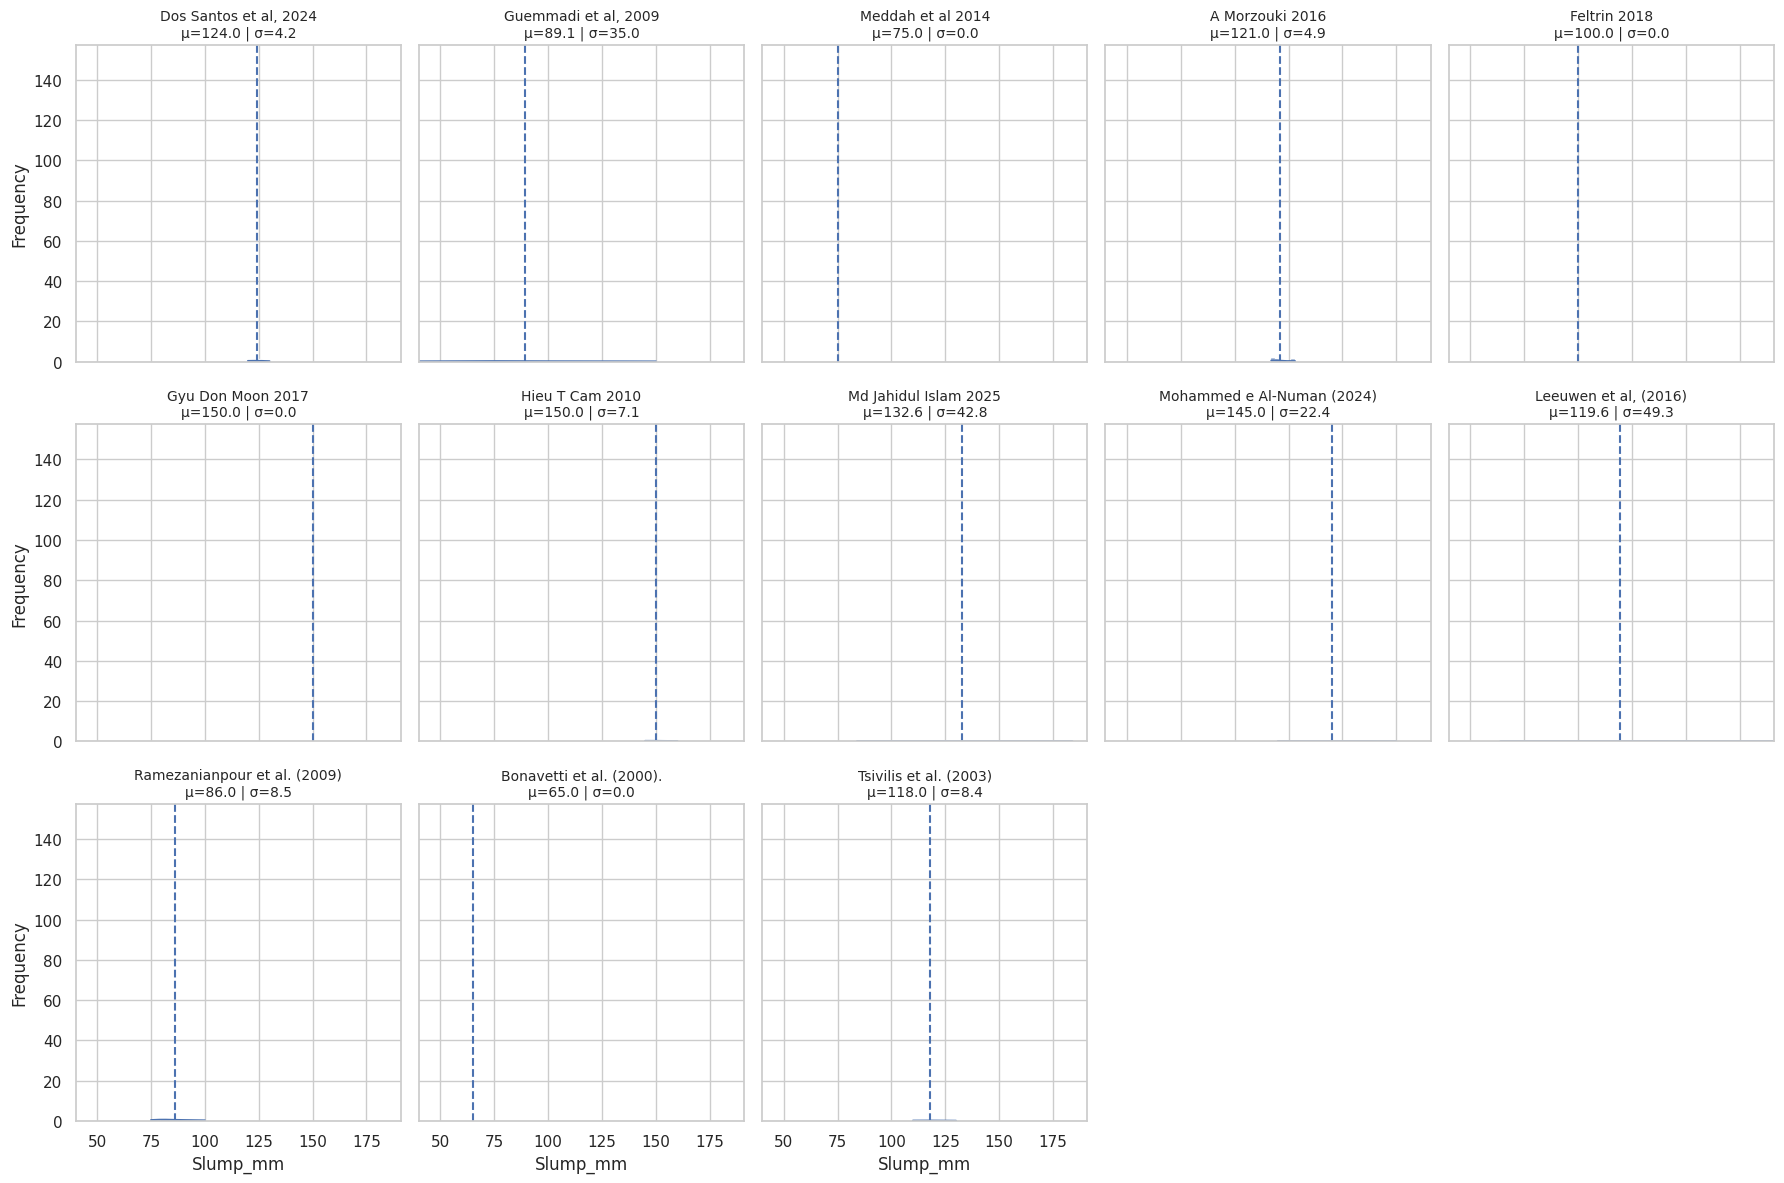

In [413]:
sns.set_style("whitegrid")
autores = df_slump['Autores/ano'].unique()
fig, axes = plt.subplots(
    nrows=3,
    ncols=int(np.ceil(len(autores) / 3)),
    figsize=(18, 4*3),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

xmin = df_slump['Slump_mm'].min()
xmax = df_slump['Slump_mm'].max()

for i, autor in enumerate(autores):

    df_autor = df_slump[
        df_slump['Autores/ano'] == autor
    ]
    media = df_autor['Slump_mm'].mean()
    std = df_autor['Slump_mm'].std()
    sns.histplot(
        data=df_autor,
        x='Slump_mm',
        bins=6,
        kde=True,
        stat='frequency',
        ax=axes[i]
    )
    axes[i].axvline(
        media,
        linestyle='--'
    )
    axes[i].set_title(
        f'{autor}\nμ={media:.1f} | σ={std:.1f}',
        fontsize=10
    )
    axes[i].set_xlim(xmin, xmax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [414]:
df_slump.groupby('Autores/ano')['Slump_mm'].agg(['count','std'])

,count,std
Autores/ano,,
A Morzouki 2016,7,4.898979
Bonavetti et al. (2000).,2,0.000000
"Dos Santos et al, 2024",5,4.183300
Feltrin 2018,12,0.000000
"Guemmadi et al, 2009",23,35.021168
Gyu Don Moon 2017,8,0.000000
Hieu T Cam 2010,4,7.071068
"Leeuwen et al, (2016)",10,49.313510
Md Jahidul Islam 2025,5,42.787849


In [415]:
df_slump["Usa_SP"] = df_slump["Usa_SP"].astype(bool)

In [416]:
# 1. Preparação das colunas originais
colunas_originais_cluster = [
    'Cimento_kg_m3', 
    'Filer_Calcario_kg_m3', 
    'Agua_kg_m3', 
    'Agregado_Miudo_Total_kg_m3', 
    'Agregado_Graudo_Total_kg_m3', 
    'Superplastificante_kg_m3',
    'Relacao_Agua_Aglomerante'
]

# 2. Tratamento rápido de nulos para o SP
df_slump['Superplastificante_kg_m3'] = df_slump['Superplastificante_kg_m3'].fillna(0)

# 3. Scaling (Mandatório!)
scaler = StandardScaler()
X_originais_scaled = scaler.fit_transform(df_slump[colunas_originais_cluster])

# 4. HDBSCAN
hdbscan_orig = HDBSCAN(
    min_cluster_size=5,
    min_samples=2,
    cluster_selection_epsilon=0.5, # Valor inicial para dados padronizados
    metric='euclidean'
)

df_slump['Cluster_ID'] = hdbscan_orig.fit_predict(X_originais_scaled)

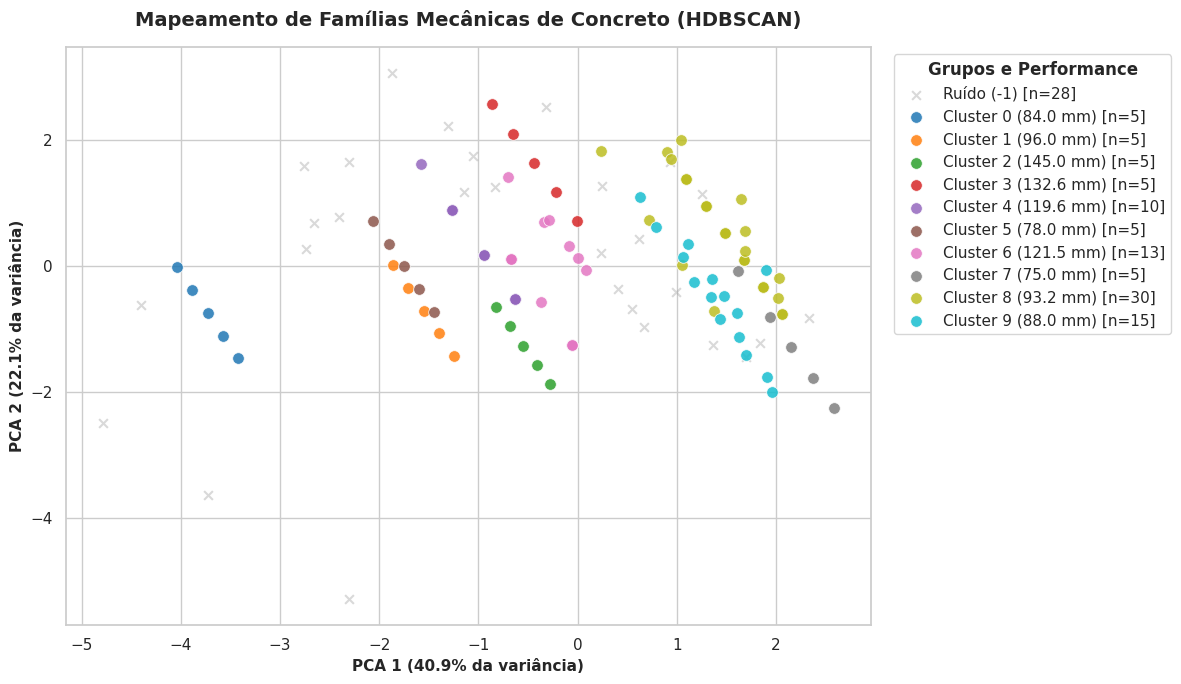

In [417]:
# 1. Redução para 2D e captura da variância explicada
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_originais_scaled)

df_plot = df_slump.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

# Extraindo a importância de cada componente para os eixos
var_explicada = pca.explained_variance_ratio_ * 100

# 2. Configuração estética do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Criando uma paleta de cores viva apenas para os clusters válidos
clusters_validos = [c for c in sorted(df_plot["Cluster_ID"].unique()) if c != -1]
palette = sns.color_palette("tab10", n_colors=len(clusters_validos))

color_idx = 0
for cluster in sorted(df_plot["Cluster_ID"].unique()):
    subset = df_plot[df_plot["Cluster_ID"] == cluster]
    
    if cluster == -1:
        # Ruído fica em segundo plano: cinza, apagado e com marcador 'x'
        plt.scatter(
            subset["PCA1"], subset["PCA2"], 
            color="#A0A0A0", alpha=0.4, marker="x", s=40, 
            label=f"Ruído (-1) [n={len(subset)}]"
        )
    else:
        # Clusters válidos: cores marcantes e info da média de Slump na legenda
        media_slump = subset["Slump_mm"].mean()
        plt.scatter(
            subset["PCA1"], subset["PCA2"], 
            color=palette[color_idx], alpha=0.85, edgecolors="w", s=70, linewidths=0.6,
            label=f"Cluster {cluster} ({media_slump:.1f} mm) [n={len(subset)}]"
        )
        color_idx += 1

# 3. Customização de eixos com a variância do PCA
plt.xlabel(f"PCA 1 ({var_explicada[0]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.ylabel(f"PCA 2 ({var_explicada[1]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.title("Mapeamento de Famílias Mecânicas de Concreto (HDBSCAN)", fontsize=14, fontweight='bold', pad=15)

# CORREÇÃO AQUI: Criamos a legenda e depois aplicamos o negrito no título dela
legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Grupos e Performance", frameon=True)
legend.get_title().set_fontweight('bold') 

plt.tight_layout()
plt.show()

# ==========================================
# 4. PÓS-PROCESSAMENTO
# ==========================================
df_slump_limpo = df_slump[df_slump['Cluster_ID'] != -1].copy()

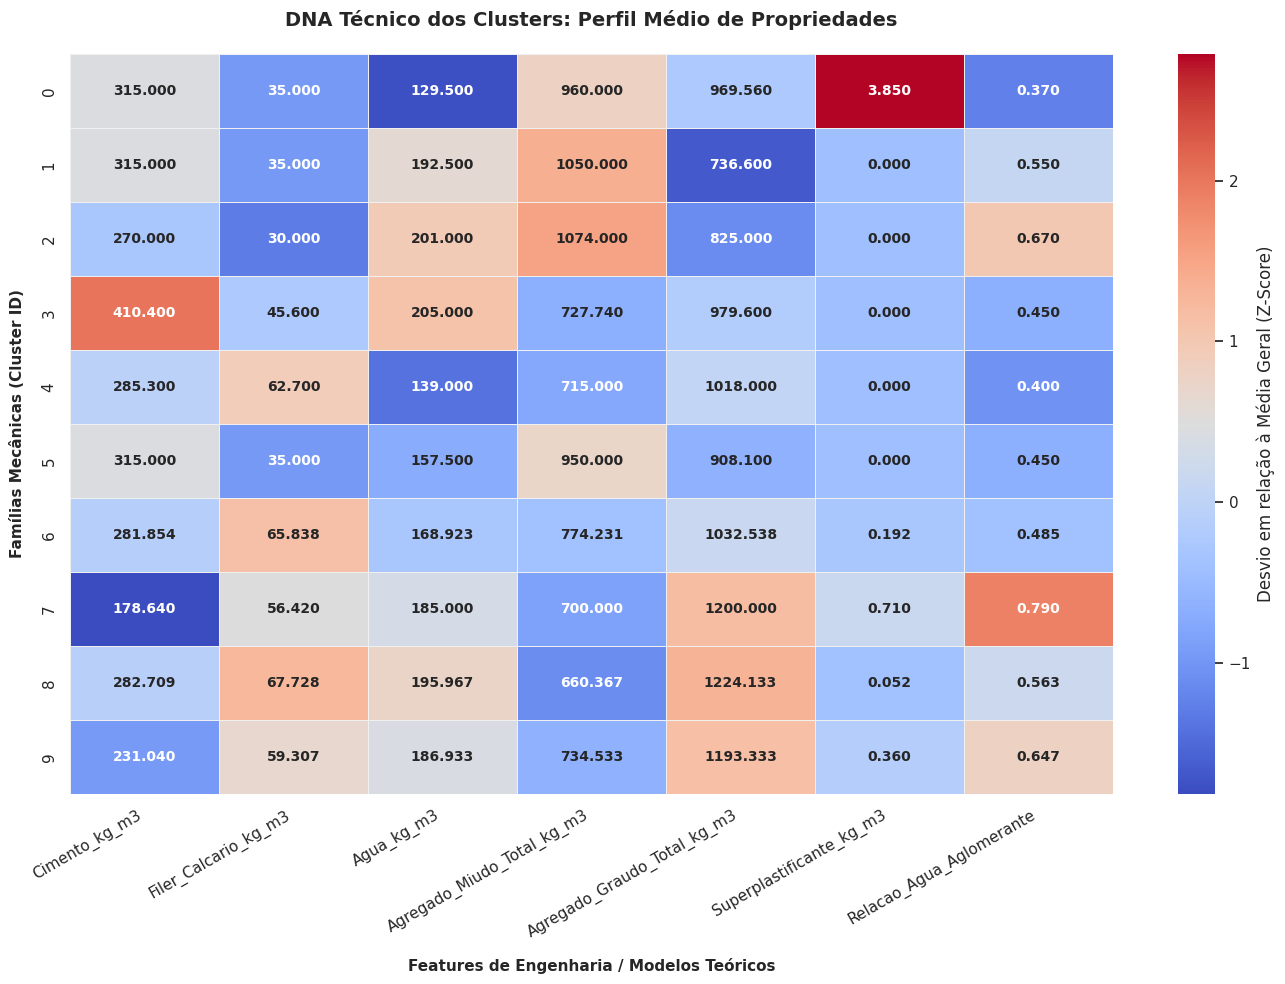

In [418]:
# 1. Calculando a média real por cluster
cluster_profile_raw = (
    df_slump_limpo
    .groupby("Cluster_ID")[colunas_originais_cluster]
    .mean()
)

# 2. O Pulo do Gato: Padronização apenas para a escala de CORES
# Isso diz quantos desvios padrões o cluster está acima (vermelho) ou abaixo (azul) da média geral
cluster_profile_scaled = (cluster_profile_raw - cluster_profile_raw.mean()) / cluster_profile_raw.std()

# 3. Configuração da figura (mais alta para caber os 18 clusters sem espremer)
plt.figure(figsize=(14, 10))

# 4. Construindo o Heatmap Inteligente
sns.heatmap(
    cluster_profile_scaled, 
    annot=cluster_profile_raw.values, # <-- EXIBE OS VALORES REAIS
    fmt=".3f",                        # <-- Formata com 3 casas decimais
    cmap="coolwarm",                  # <-- Azul (Abaixo da média) | Vermelho (Acima da média)
    linewidths=0.7,                   # <-- Linha fina para separar os blocos
    linecolor="#F0F0F0",
    cbar_kws={'label': 'Desvio em relação à Média Geral (Z-Score)'},
    annot_kws={"size": 10, "weight": "semibold"} # Texto interno legível
)

# 5. Ajustes estéticos e labels
plt.title("DNA Técnico dos Clusters: Perfil Médio de Propriedades", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Features de Engenharia / Modelos Teóricos", fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=12)
plt.xticks(rotation=30, ha="right") # Rotaciona os nomes das colunas para não encavalar
plt.tight_layout()
plt.show()

/tmp/ipykernel_44435/3592450497.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


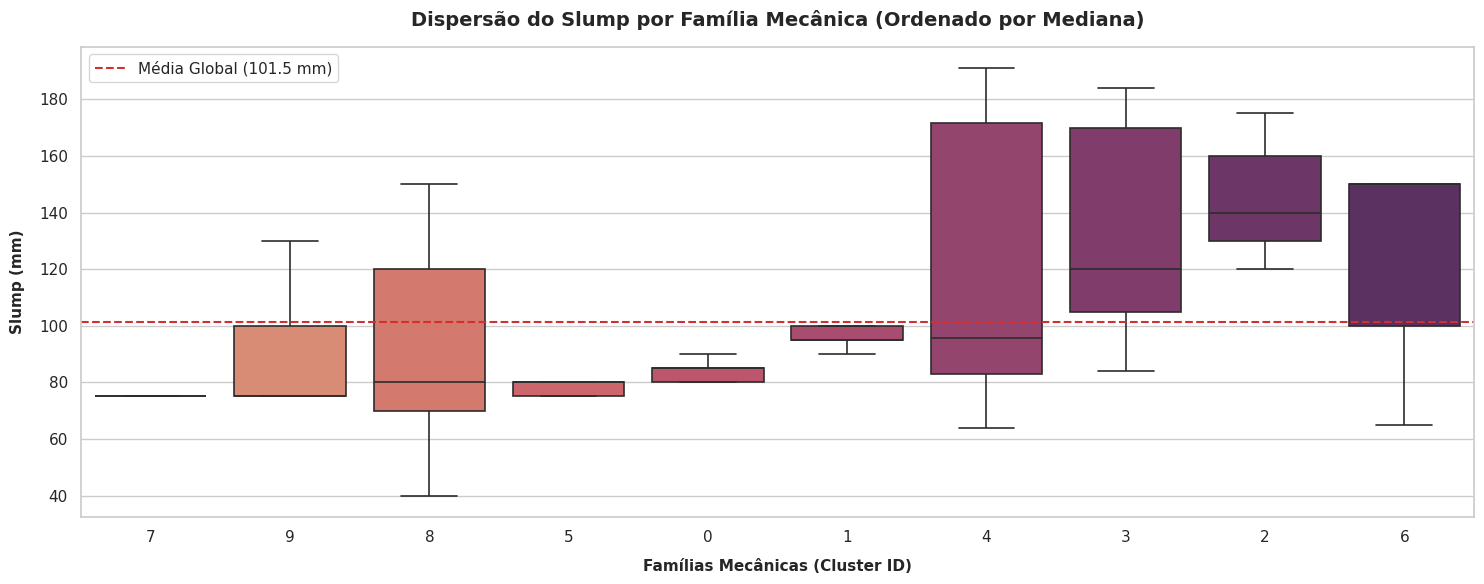

In [419]:
# 1. O TRUQUE DE MESTRE: Descobrir a ordem dos clusters baseada na MEDIANA do Slump para criar um boxplot em escada
ordem_clusters = (
    df_slump_limpo
    .groupby("Cluster_ID")["Slump_mm"]
    .median()
    .sort_values()
    .index
)

# 2. Configuração estética do ambiente
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6)) # Aumentamos a largura para acomodar os 18 grupos sem espremer

# 3. Plot do Boxplot ordenado com uma paleta de degradê (flare ou viridis)
sns.boxplot(
    data=df_slump_limpo, 
    x="Cluster_ID", 
    y="Slump_mm",
    order=ordem_clusters,     # <-- Aplica a ordenação em escada
    palette="flare",          # <-- Cria um degradê suave acompanhando a subida
    linewidth=1.2,
    fliersize=4               # Tamanho dos outliers internos de cada cluster
)

# 4. Adiciona uma linha horizontal com a média global da base de dados
media_global = df_slump_limpo["Slump_mm"].mean()
plt.axhline(
    media_global, 
    color="#D32F2F", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"Média Global ({media_global:.1f} mm)"
)

# 5. Ajustes finais de polimento
plt.title("Dispersão do Slump por Família Mecânica (Ordenado por Mediana)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Slump (mm)", fontsize=11, fontweight='bold', labelpad=10)

# Como a figura está larga, rotação 0 ou 30 já é suficiente para leitura
plt.xticks(rotation=0) 

plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [420]:
# Verificando se os clusters fazem sentido
analise_slump = df_slump_limpo.groupby('Cluster_ID')['Slump_mm'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_slump)

                  mean        std  count  min  max
Cluster_ID                                        
0            84.000000   4.183300      5   80   90
1            96.000000   4.183300      5   90  100
2           145.000000  22.360680      5  120  175
3           132.600000  42.787849      5   84  184
4           119.600000  49.313510     10   64  191
5            78.000000   2.738613      5   75   80
6           121.538462  34.057832     13   65  150
7            75.000000   0.000000      5   75   75
8            93.233333  33.557653     30   40  150
9            88.000000  20.684708     15   75  130


In [421]:
df_slump.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Autores/ano                      126 non-null    object 
 1   ID_Mistura                       126 non-null    object 
 2   Tipo_Cimento_Classe              126 non-null    object 
 3   Massa_Esp_Cimento_g_cm3          110 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg      93 non-null     float64
 5   Massa_Esp_Filer_g_cm3            83 non-null     float64
 6   Finura_Filer_Blaine_m2_kg        65 non-null     float64
 7   Filer_D50_um                     72 non-null     float64
 8   Massa_Esp_Areia_g_cm3            78 non-null     float64
 9   Massa_Esp_Brita_g_cm3            78 non-null     float64
 10  D_Max                            92 non-null     float64
 11  Cimento_kg_m3                    126 non-null    float64
 12  Filer_Calcario_kg_m3  

In [422]:
# ==========================================
# CONSTANTES
# ==========================================
# 1. Definimos a lista dos materiais que precisam da correção de densidade
colunas_densidade = [
    'Massa_Esp_Cimento_g_cm3',
    'Massa_Esp_Areia_g_cm3',
    'Massa_Esp_Brita_g_cm3',
    'Massa_Esp_Filer_g_cm3',
    'Superplastificante_kg_m3',
    'D_Max', 'Filer_D50_um',
    'Finura_Cimento_Blaine_m2_kg',
    'Finura_Filer_Blaine_m2_kg',
    'Densidade_Concreto_Fresco_kg_m3'
]

for col in colunas_densidade:
    # Passo A: Imputação com Média do próprio Cluster
    df_slump_limpo[col] = df_slump_limpo.groupby('Cluster_ID')[col].transform(
        lambda x: x.fillna(x.mean())
    )
    
    # Passo B: A Trava de Segurança (Fallback para a Média Global)
    media_global = df_slump_limpo[col].mean()
    df_slump_limpo[col] = df_slump_limpo[col].fillna(media_global)
    
    # Verificação em tempo real
    nulos_restantes = df_slump_limpo[col].isna().sum()
    print(f"✅ {col}: {nulos_restantes} nulos restantes.")

# Tratamento especifico para Superplastificante_kg_m3 que depende diretamente de Usa_SP
df_slump_limpo.loc[~df_slump_limpo['Usa_SP'], 'Superplastificante_kg_m3'] = 0.0

# Quando não há filler seu tamanho deve ser 0, não faz sentido ter um D50.
df_slump_limpo.loc[df_slump_limpo['Filer_Calcario_kg_m3'] == 0, 'Filer_D50_um'] = 0.0

df_slump_limpo['Massa_Esp_Cimento_kg_m3'] = df_slump_limpo['Massa_Esp_Cimento_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump_limpo['Massa_Esp_Areia_kg_m3'] =  df_slump_limpo['Massa_Esp_Areia_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump_limpo['Massa_Esp_Brita_kg_m3'] = df_slump_limpo['Massa_Esp_Brita_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump_limpo['Massa_Esp_Filer_kg_m3'] = df_slump_limpo['Massa_Esp_Filer_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_slump_limpo.drop(columns=['Massa_Esp_Cimento_g_cm3', 'Massa_Esp_Areia_g_cm3', 'Massa_Esp_Brita_g_cm3', 'Massa_Esp_Filer_g_cm3'], inplace=True)

# 2. Atualizando as variáveis que vão alimentar a sua matriz de volumes absolutos
DENSIDADE_CIMENTO = df_slump_limpo['Massa_Esp_Cimento_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AREIA = df_slump_limpo['Massa_Esp_Areia_kg_m3']  # Usando a coluna já convertida
DENSIDADE_BRITA = df_slump_limpo['Massa_Esp_Brita_kg_m3']  # Usando a coluna já convertida
DENSIDADE_FILER = df_slump_limpo['Massa_Esp_Filer_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AGUA = 1000
DENSIDADE_SP = 1100

K_AGUA_CIMENTO = 0.22
K_AGUA_FILER = 0.10
K_EQUIV_SP = 15.0
VOID_RATIO_AGREGADOS = 0.35

✅ Massa_Esp_Cimento_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Areia_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Brita_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Filer_g_cm3: 0 nulos restantes.
✅ Superplastificante_kg_m3: 0 nulos restantes.
✅ D_Max: 0 nulos restantes.
✅ Filer_D50_um: 0 nulos restantes.
✅ Finura_Cimento_Blaine_m2_kg: 0 nulos restantes.
✅ Finura_Filer_Blaine_m2_kg: 0 nulos restantes.
✅ Densidade_Concreto_Fresco_kg_m3: 0 nulos restantes.


In [423]:
EPS = np.finfo(float).eps

# ==========================================
# 1. TRATAMENTO DE DADOS
# ==========================================
df_slump_limpo['Superplastificante_kg_m3'] = df_slump_limpo['Superplastificante_kg_m3'].fillna(0)
df_slump_limpo.drop(['Filer_D50_um'], axis=1, inplace=True, errors='ignore')
df_slump_limpo['D_Max'] = df_slump_limpo['D_Max'].fillna(df_slump_limpo['D_Max'].median())

# ==========================================
# 2. CONVERSÃO MASSA → VOLUME (m³/m³)
# ==========================================
df_slump_limpo['vol_cimento'] = pd.to_numeric(df_slump_limpo['Cimento_kg_m3'], errors='coerce') / DENSIDADE_CIMENTO
df_slump_limpo['vol_filer'] = pd.to_numeric(df_slump_limpo['Filer_Calcario_kg_m3'], errors='coerce') / DENSIDADE_FILER
df_slump_limpo['vol_agua'] = pd.to_numeric(df_slump_limpo['Agua_kg_m3'], errors='coerce') / DENSIDADE_AGUA
df_slump_limpo['vol_areia'] = pd.to_numeric(df_slump_limpo['Agregado_Miudo_Total_kg_m3'], errors='coerce') / DENSIDADE_AREIA
df_slump_limpo['vol_brita'] = pd.to_numeric(df_slump_limpo['Agregado_Graudo_Total_kg_m3'], errors='coerce') / DENSIDADE_BRITA
df_slump_limpo['vol_sp'] = pd.to_numeric(df_slump_limpo['Superplastificante_kg_m3'], errors='coerce') / DENSIDADE_SP

# ==========================================
# 3. FECHAMENTO VOLUMÉTRICO
# ==========================================
volume_materiais = (
    df_slump_limpo['vol_cimento'] + df_slump_limpo['vol_filer'] + df_slump_limpo['vol_agua'] +
    df_slump_limpo['vol_areia'] + df_slump_limpo['vol_brita'] + df_slump_limpo['vol_sp']
)

df_slump_limpo['vol_ar_aprisionado'] = (1.0 - volume_materiais).clip(lower=0)

# ==========================================
# 4. AGRUPAMENTOS
# ==========================================
df_slump_limpo['vol_aglomerante'] = df_slump_limpo['vol_cimento'] + df_slump_limpo['vol_filer']
df_slump_limpo['vol_agregados'] = df_slump_limpo['vol_areia'] + df_slump_limpo['vol_brita']

df_slump_limpo['vol_pasta'] = (
    df_slump_limpo['vol_aglomerante'] +
    df_slump_limpo['vol_agua'] +
    df_slump_limpo['vol_sp'] +
    df_slump_limpo['vol_ar_aprisionado']
)

df_slump_limpo['vol_argamassa'] = df_slump_limpo['vol_pasta'] + df_slump_limpo['vol_areia']

# 🔧 Correção: evitar propagação de erro numérico
df_slump_limpo['vol_total'] = 1.0

# ==========================================
# 5. ÁGUA EFETIVA
# ==========================================
df_slump_limpo['massa_aglomerante_total'] = (
    df_slump_limpo['Cimento_kg_m3'] + df_slump_limpo['Filer_Calcario_kg_m3']
)

agua_adsorvida = (
    K_AGUA_CIMENTO * df_slump_limpo['Cimento_kg_m3'] +
    K_AGUA_FILER * df_slump_limpo['Filer_Calcario_kg_m3']
)

df_slump_limpo['vol_agua_livre'] = (
    (df_slump_limpo['Agua_kg_m3'] - agua_adsorvida).clip(lower=0)
) / DENSIDADE_AGUA

# ==========================================
# 6. FRAÇÕES
# ==========================================
df_slump_limpo['fracao_vol_pasta'] = df_slump_limpo['vol_pasta']
df_slump_limpo['fracao_vol_argamassa'] = df_slump_limpo['vol_argamassa']

# ==========================================
# 7. RELAÇÕES
# ==========================================
df_slump_limpo['agua_aglomerante_vol'] = df_slump_limpo['vol_agua'] / df_slump_limpo['vol_aglomerante'].clip(lower=EPS)

df_slump_limpo['relacao_areia_brita_vol'] = df_slump_limpo['vol_areia'] / df_slump_limpo['vol_brita'].clip(lower=EPS)

df_slump_limpo['fator_areia_agregado'] = df_slump_limpo['vol_areia'] / df_slump_limpo['vol_agregados'].clip(lower=EPS)

# 🔧 Correção: agora representa melhor pasta vs esqueleto granular
df_slump_limpo['teor_pasta_relativo'] = df_slump_limpo['vol_pasta'] / df_slump_limpo['vol_agregados'].clip(lower=EPS)

df_slump_limpo['filer_sobre_cimento_vol'] = df_slump_limpo['vol_filer'] / df_slump_limpo['vol_cimento'].clip(lower=EPS)

# ==========================================
# 8. LUBRIFICAÇÃO
# ==========================================
df_slump_limpo['agua_equivalente_vol'] = df_slump_limpo['vol_agua'] + K_EQUIV_SP * df_slump_limpo['vol_sp']

df_slump_limpo['indice_lubrificacao_global'] = (
    df_slump_limpo['agua_equivalente_vol'] / df_slump_limpo['vol_brita'].clip(lower=EPS)
)

# ==========================================
# 9. REOLOGIA
# ==========================================
df_slump_limpo['particle_crowding_index'] = (
    df_slump_limpo['vol_agregados'] / df_slump_limpo['vol_pasta'].clip(lower=EPS)
)

# 🔧 Correção: não pode ser negativo
df_slump_limpo['vol_pasta_livre'] = (
    df_slump_limpo['vol_pasta'] - VOID_RATIO_AGREGADOS * df_slump_limpo['vol_agregados']
).clip(lower=0)

# 🔧 Correção: área mais coerente fisicamente
df_slump_limpo['area_superficial_proxy'] = (
    df_slump_limpo['vol_areia'] / 0.2 +   # D_areia ~ 0.2 mm
    df_slump_limpo['vol_brita'] / df_slump_limpo['D_Max'].clip(lower=EPS)
)

df_slump_limpo['paste_film_thickness'] = (
    df_slump_limpo['vol_pasta_livre'] / df_slump_limpo['area_superficial_proxy'].clip(lower=EPS)
)

df_slump_limpo['rigidez_pasta'] = (
    df_slump_limpo['vol_aglomerante'] / df_slump_limpo['agua_equivalente_vol'].clip(lower=EPS)
)

df_slump_limpo['yield_stress_proxy'] = (
    df_slump_limpo['rigidez_pasta'] * df_slump_limpo['particle_crowding_index']
)

# ==========================================
# 10. SEGREGAÇÃO
# ==========================================
df_slump_limpo['agua_sobre_areia'] = df_slump_limpo['vol_agua'] / df_slump_limpo['vol_areia'].clip(lower=EPS)

df_slump_limpo['potencial_segregacao'] = (
    df_slump_limpo['agua_sobre_areia'] / df_slump_limpo['teor_pasta_relativo'].clip(lower=EPS)
)

# ==========================================
# 11. FEATURES FINAIS
# ==========================================
df_slump_limpo['fluido_lubrificante_total'] = (
    df_slump_limpo['vol_agua'] + df_slump_limpo['vol_ar_aprisionado']
)

df_slump_limpo['vol_finos_reconstruido'] = (
    df_slump_limpo['teor_pasta_relativo'] * df_slump_limpo['vol_agregados']
)

df_slump_limpo['fator_agua_finos'] = (
    df_slump_limpo['vol_agua'] / df_slump_limpo['vol_finos_reconstruido'].clip(lower=EPS)
)

df_slump_limpo['lubrificacao_efetiva'] = (
    df_slump_limpo['indice_lubrificacao_global'] /
    (1 + df_slump_limpo['potencial_segregacao'])
)

# ==========================================
# 12. LEIS CLÁSSICAS (ABRAMS, LYSE, MOLINARI)
# ==========================================

# --- LEI DE ABRAMS (Qualidade e Fluidez da Pasta) ---
# Representa a mobilidade potencial. Quanto maior o w/c, maior o potencial de Slump.
df_slump_limpo['abrams_mobility_factor'] = np.exp(df_slump_limpo['Relacao_Agua_Aglomerante'])

# --- LEI DE LYSE (Volume de Água e Sólidos) ---
# Lyse puro: Água por volume de sólidos (Cimento + Filer + Areia + Brita)
vol_solidos = (df_slump_limpo['vol_cimento'] + df_slump_limpo['vol_filer'] + 
               df_slump_limpo['vol_areia'] + df_slump_limpo['vol_brita'])

df_slump_limpo['lyse_water_demand'] = df_slump_limpo['vol_agua'] / vol_solidos.clip(lower=EPS)

# --- LEI DE MOLINARI (Teor de Argamassa - Alpha) ---
# Representa a proporção de matriz fina que "carrega" a brita. 
# Essencial para a trabalhabilidade.
df_slump_limpo['molinari_alpha'] = df_slump_limpo['vol_argamassa'] / df_slump_limpo['vol_total']

# Uma mistura das três: Água de Lyse ajustada pelo Alpha de Molinari
df_slump_limpo['reologia_global_proxy'] = (df_slump_limpo['lyse_water_demand'] * df_slump_limpo['molinari_alpha'] * df_slump_limpo['abrams_mobility_factor'])

In [424]:
# Seleção das colunas "Cérebro do Slump"
colunas_cluster_avancado = [
    # 1. Dimensão de Fluidez (Física)
    'paste_film_thickness',   # Espessura da camada lubrificante
    'yield_stress_proxy',     # Tensão de escoamento (o "divisor" entre sólido e fluido)
    
    # 2. Dimensão de Estrutura (Leis de Molinari e Abrams)
    'molinari_alpha',         # Teor de argamassa (separa concretos "pedrentos" de "melados")
    'fator_areia_agregado',   # Esqueleto granular (crucial para o Slump)
    
    # 3. Dimensão de Intensidade (Lei de Lyse e Química)
    'lyse_water_demand',      # A "Lei de Ouro" do Slump: água por volume de sólidos
    'lubrificacao_efetiva'    # O efeito real do superplastificante + água
]

X_cluster = df_slump_limpo[colunas_cluster_avancado].copy()

# O StandardScaler aqui é ainda mais crítico devido às transformações físicas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

hdbscan_modelo = HDBSCAN(
    min_cluster_size=5, 
    min_samples=2,
    cluster_selection_epsilon=0.5,
    metric='euclidean'
)

df_slump_limpo['Cluster_ID'] = hdbscan_modelo.fit_predict(X_scaled)

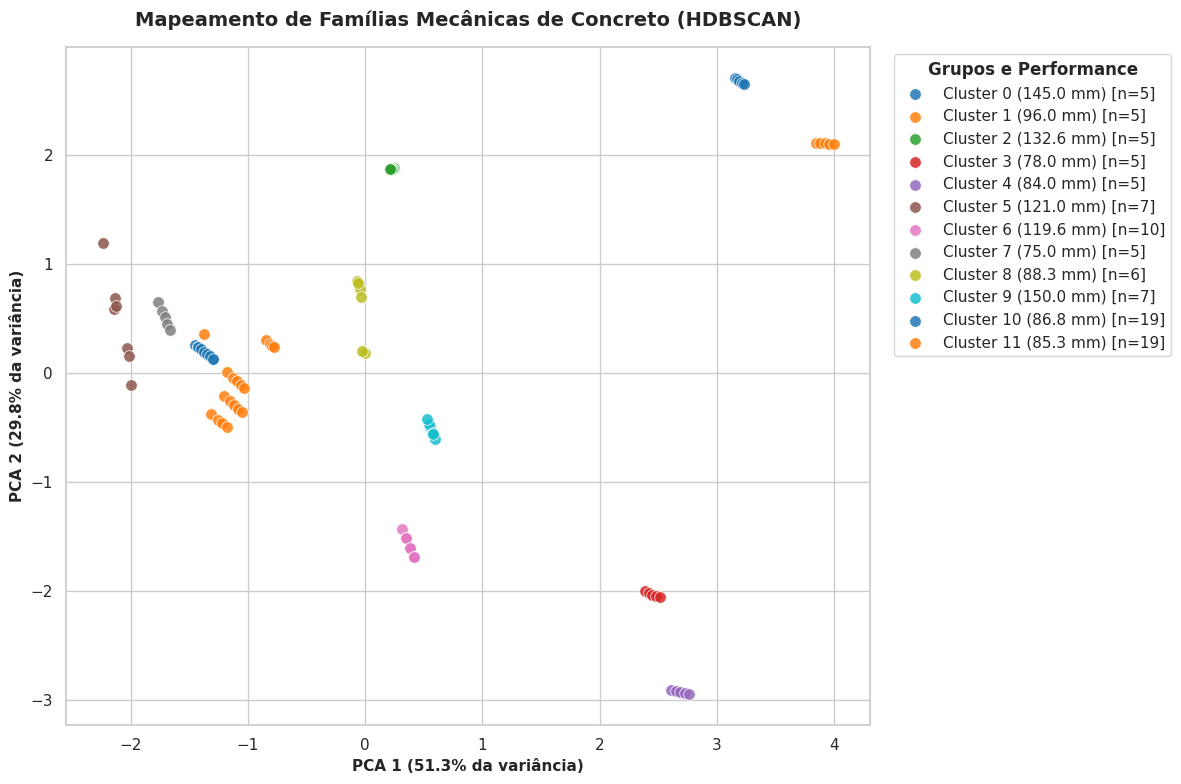

In [425]:
# 1. Redução para 2D e captura da variância explicada
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = df_slump_limpo.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

# Extraindo a importância de cada componente para os eixos
var_explicada = pca.explained_variance_ratio_ * 100

# 2. Configuração estética do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Criando uma paleta de cores viva apenas para os clusters válidos
clusters_validos = [c for c in sorted(df_plot["Cluster_ID"].unique()) if c != -1]
palette = sns.color_palette("tab10", n_colors=len(clusters_validos))

color_idx = 0
for cluster in sorted(df_plot["Cluster_ID"].unique()):
    subset = df_plot[df_plot["Cluster_ID"] == cluster]
    
    if cluster == -1:
        # Ruído fica em segundo plano: cinza, apagado e com marcador 'x'
        plt.scatter(
            subset["PCA1"], subset["PCA2"], 
            color="#A0A0A0", alpha=0.4, marker="x", s=40, 
            label=f"Ruído (-1) [n={len(subset)}]"
        )
    else:
        # Clusters válidos: cores marcantes e info da média de Slump na legenda
        media_slump = subset["Slump_mm"].mean()
        plt.scatter(
            subset["PCA1"], subset["PCA2"], 
            color=palette[color_idx], alpha=0.85, edgecolors="w", s=70, linewidths=0.6,
            label=f"Cluster {cluster} ({media_slump:.1f} mm) [n={len(subset)}]"
        )
        color_idx += 1

# 3. Customização de eixos com a variância do PCA
plt.xlabel(f"PCA 1 ({var_explicada[0]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.ylabel(f"PCA 2 ({var_explicada[1]:.1f}% da variância)", fontsize=11, fontweight='bold')
plt.title("Mapeamento de Famílias Mecânicas de Concreto (HDBSCAN)", fontsize=14, fontweight='bold', pad=15)

legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Grupos e Performance", frameon=True)
legend.get_title().set_fontweight('bold') 

plt.tight_layout()
plt.show()

# ==========================================
# 4. PÓS-PROCESSAMENTO
# ==========================================
df_slump_limpo = df_slump_limpo[df_slump_limpo['Cluster_ID'] != -1].copy()

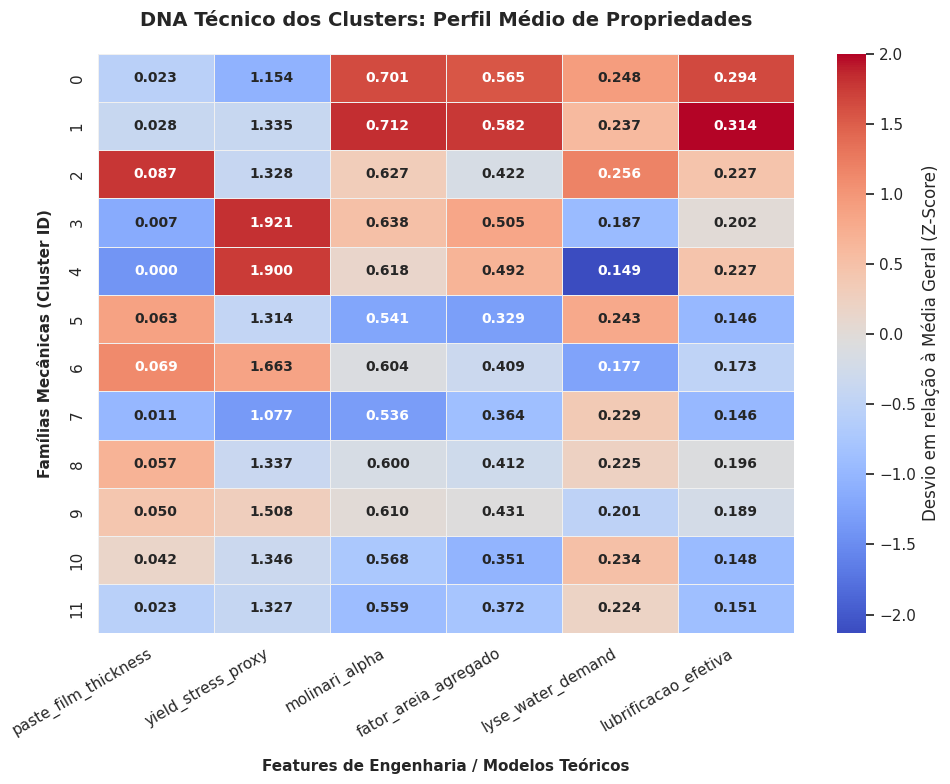

In [426]:
# 1. Filtrando o ruído para não distorcer as médias da população real
df_perfil = df_slump_limpo[df_slump_limpo['Cluster_ID'] != -1].copy()

# 2. Calculando a média real por cluster
cluster_profile_raw = (
    df_perfil
    .groupby("Cluster_ID")[colunas_cluster_avancado]
    .mean()
)

# 3. O Pulo do Gato: Padronização apenas para a escala de CORES
# Isso diz quantos desvios padrões o cluster está acima (vermelho) ou abaixo (azul) da média geral
cluster_profile_scaled = (cluster_profile_raw - cluster_profile_raw.mean()) / cluster_profile_raw.std()

# 4. Configuração da figura (mais alta para caber os 18 clusters sem espremer)
plt.figure(figsize=(10, 8))

# 5. Construindo o Heatmap Inteligente
sns.heatmap(
    cluster_profile_scaled, 
    annot=cluster_profile_raw.values, # <-- EXIBE OS VALORES REAIS
    fmt=".3f",                        # <-- Formata com 3 casas decimais
    cmap="coolwarm",                  # <-- Azul (Abaixo da média) | Vermelho (Acima da média)
    linewidths=0.7,                   # <-- Linha fina para separar os blocos
    linecolor="#F0F0F0",
    cbar_kws={'label': 'Desvio em relação à Média Geral (Z-Score)'},
    annot_kws={"size": 10, "weight": "semibold"} # Texto interno legível
)

# 6. Ajustes estéticos e labels
plt.title("DNA Técnico dos Clusters: Perfil Médio de Propriedades", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Features de Engenharia / Modelos Teóricos", fontsize=11, fontweight='bold', labelpad=12)
plt.ylabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=12)
plt.xticks(rotation=30, ha="right") # Rotaciona os nomes das colunas para não encavalar
plt.tight_layout()
plt.show()

/tmp/ipykernel_44435/2169189421.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


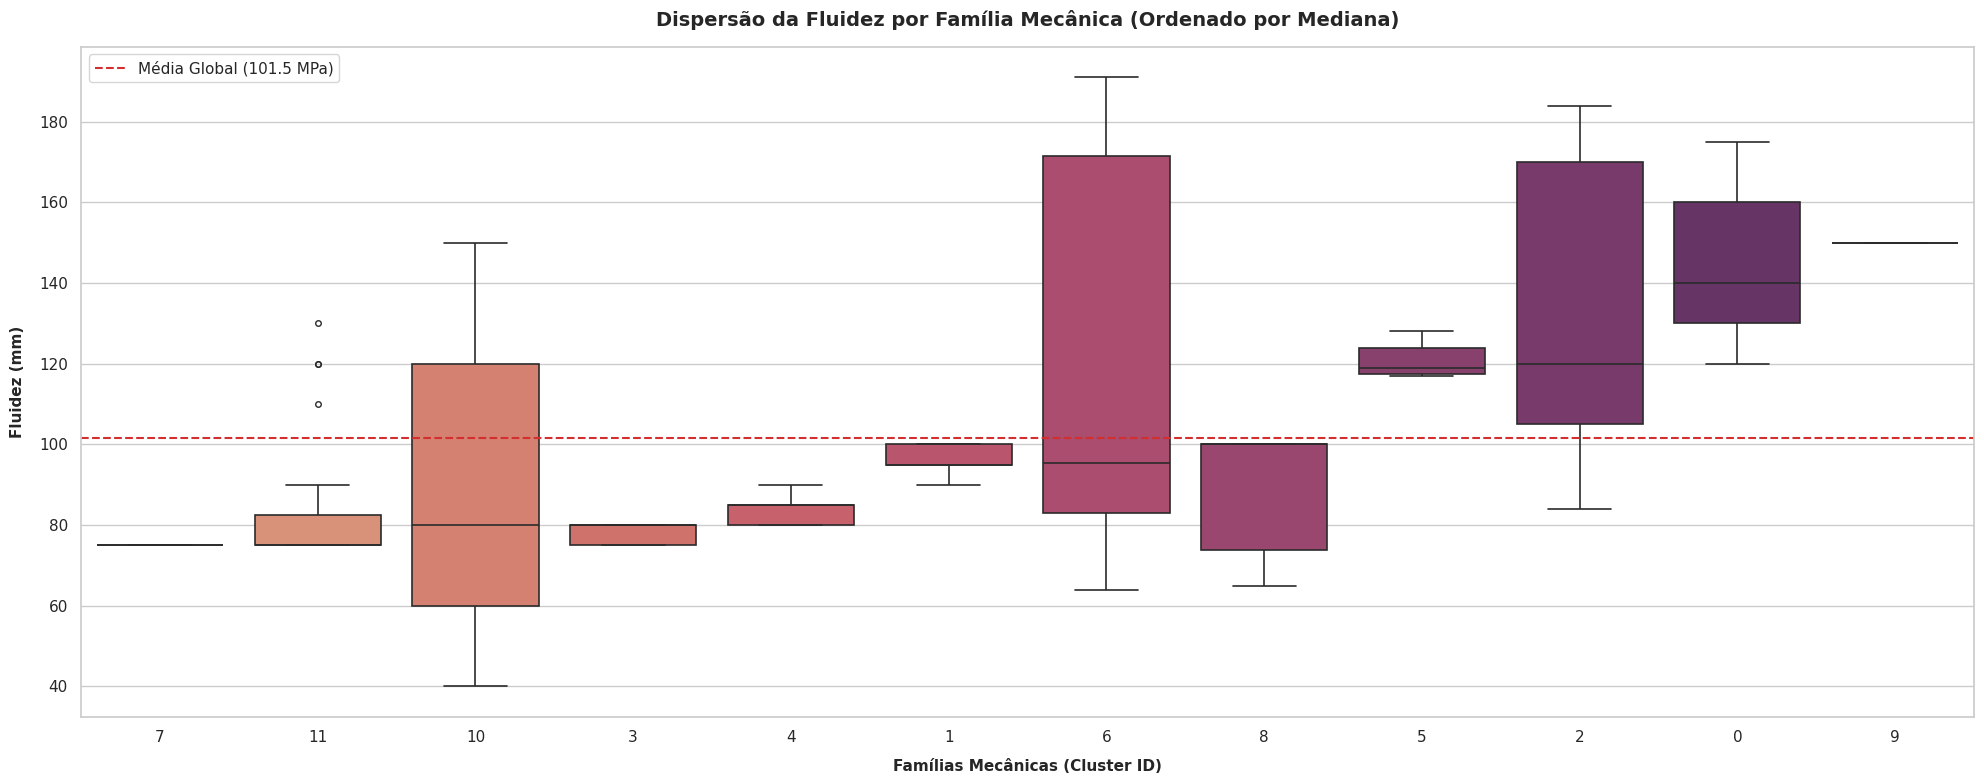

In [427]:
# 1. O TRUQUE DE MESTRE: Descobrir a ordem dos clusters baseada na MEDIANA da fluidez
ordem_clusters = (
    df_slump_limpo  
    .groupby("Cluster_ID")["Slump_mm"]
    .median()
    .sort_values()
    .index
)

# 2. Configuração estética do ambiente
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 8))

# 3. Plot do Boxplot ordenado com uma paleta de degradê (flare ou viridis)
sns.boxplot(
    data=df_slump_limpo, 
    x="Cluster_ID", 
    y="Slump_mm",
    order=ordem_clusters,     # <-- Aplica a ordenação em escada
    palette="flare",          # <-- Cria um degradê suave acompanhando a subida
    linewidth=1.2,
    fliersize=4               # Tamanho dos outliers internos de cada cluster
)

# 4. Adiciona uma linha horizontal com a média global da base de dados
media_global = df_slump_limpo["Slump_mm"].mean()
plt.axhline(
    media_global, 
    color="#D32F2F", 
    linestyle="--", 
    linewidth=1.5, 
    label=f"Média Global ({media_global:.1f} MPa)"
)

# 5. Ajustes finais de polimento
plt.title("Dispersão da Fluidez por Família Mecânica (Ordenado por Mediana)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Famílias Mecânicas (Cluster ID)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Fluidez (mm)", fontsize=11, fontweight='bold', labelpad=10)

# Como a figura está larga, rotação 0 ou 30 já é suficiente para leitura
plt.xticks(rotation=0) 

plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

In [428]:
# Verificando se os clusters fazem sentido para a fluidez (Slump)
analise_slump = df_slump_limpo.groupby('Cluster_ID')['Slump_mm'].agg(['mean', 'std', 'count', 'min', 'max'])
print(analise_slump)

                  mean        std  count  min  max
Cluster_ID                                        
0           145.000000  22.360680      5  120  175
1            96.000000   4.183300      5   90  100
2           132.600000  42.787849      5   84  184
3            78.000000   2.738613      5   75   80
4            84.000000   4.183300      5   80   90
5           121.000000   4.898979      7  117  128
6           119.600000  49.313510     10   64  191
7            75.000000   0.000000      5   75   75
8            88.333333  18.073922      6   65  100
9           150.000000   0.000000      7  150  150
10           86.842105  37.275645     19   40  150
11           85.263158  19.037513     19   75  130


In [429]:
ALVO = 'Slump_mm' 

whitelist_features = [
    'vol_cimento',
    'vol_filer',
    'Relacao_Agua_Aglomerante',
    'vol_sp'
]

# 1. Correlação
corr_matrix = df_slump.corr(method='spearman', numeric_only=True).abs()
corr_com_alvo = corr_matrix[ALVO].drop(ALVO)

limite_colinearidade = 0.95
features_para_remover = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]

        if col_i == ALVO or col_j == ALVO:
            continue

        if corr_matrix.iloc[i, j] > limite_colinearidade:

            if col_i in whitelist_features and col_j in whitelist_features:
                continue
            elif col_i in whitelist_features and col_j not in whitelist_features:
                features_para_remover.add(col_j)
                continue
            elif col_j in whitelist_features and col_i not in whitelist_features:
                features_para_remover.add(col_i)
                continue

            # lógica original
            if corr_com_alvo[col_i] > corr_com_alvo[col_j]:
                features_para_remover.add(col_j)
            else:
                features_para_remover.add(col_i)

print(f"Features removidas por colinearidade: {features_para_remover}")

df_filtrado = df_slump_limpo.drop(columns=features_para_remover)

Features removidas por colinearidade: {'cod_empacotamento', 'ln_Idade', 'Classe_Cim_OpB', 'cod_substituicao', 'Superplastificante_kg_m3', 'Superplast_%_cement', 'cod_geometria'}


In [430]:
df_filtrado.columns

Index(['Autores/ano', 'ID_Mistura', 'Tipo_Cimento_Classe',
       'Finura_Cimento_Blaine_m2_kg', 'Finura_Filer_Blaine_m2_kg', 'D_Max',
       'Cimento_kg_m3', 'Filer_Calcario_kg_m3', 'Agua_kg_m3',
       'Agregado_Miudo_Total_kg_m3', 'Agregado_Graudo_Total_kg_m3',
       'Relacao_Agua_Cimento', 'Relacao_Agua_Aglomerante',
       'Metodo_Empacotamento', 'Metodo_Substituicao', 'Idade_Dias', 'Slump_mm',
       'Densidade_Concreto_Fresco_kg_m3', 'Tipo_Molde_Geometria',
       'Resistencia_Compressao_MPa', 'Tipo_Molde_Cod', 'Classe_Cim_OpA',
       'Metodo_Emp_Cod', 'Metodo_Sub_Cod', 'Usa_SP', 'cod_classe',
       'Cluster_ID', 'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Areia_kg_m3',
       'Massa_Esp_Brita_kg_m3', 'Massa_Esp_Filer_kg_m3', 'vol_cimento',
       'vol_filer', 'vol_agua', 'vol_areia', 'vol_brita', 'vol_sp',
       'vol_ar_aprisionado', 'vol_aglomerante', 'vol_agregados', 'vol_pasta',
       'vol_argamassa', 'vol_total', 'massa_aglomerante_total',
       'vol_agua_livre', 'fracao_vo

In [431]:
df_filtrado.corr(method='spearman', numeric_only=True)['Slump_mm'].abs().sort_values(ascending=False)

,Slump_mm
Slump_mm,1.000000
Tipo_Molde_Cod,0.500260
fluido_lubrificante_total,0.438860
vol_pasta_livre,0.416350
teor_pasta_relativo,0.414014
...,...
vol_cimento,0.037408
Relacao_Agua_Cimento,0.031053
yield_stress_proxy,0.027544
agua_equivalente_vol,0.013150


In [432]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 5 to 124
Data columns (total 70 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Autores/ano                      98 non-null     object 
 1   ID_Mistura                       98 non-null     object 
 2   Tipo_Cimento_Classe              98 non-null     object 
 3   Finura_Cimento_Blaine_m2_kg      98 non-null     float64
 4   Finura_Filer_Blaine_m2_kg        98 non-null     float64
 5   D_Max                            98 non-null     float64
 6   Cimento_kg_m3                    98 non-null     float64
 7   Filer_Calcario_kg_m3             98 non-null     float64
 8   Agua_kg_m3                       98 non-null     float64
 9   Agregado_Miudo_Total_kg_m3       98 non-null     float64
 10  Agregado_Graudo_Total_kg_m3      98 non-null     float64
 11  Relacao_Agua_Cimento             98 non-null     float64
 12  Relacao_Agua_Aglomerante    

In [433]:
df_filtrado.drop(columns=["Metodo_Empacotamento", "Metodo_Substituicao", "Tipo_Cimento_Classe", "ID_Mistura", "Tipo_Molde_Geometria"], inplace=True)

In [434]:
# 1. Preparando os dados e ISOLANDO o Grupo
grupos_isolamento = df_filtrado['Autores/ano'].copy()
whitelist_coluns = df_filtrado[whitelist_features].copy()
df_filtrado.drop(columns=whitelist_coluns.columns, inplace=True)
df_filtrado.drop(columns=['Autores/ano'], inplace=True)

X = df_filtrado.copy()
y = df_filtrado[ALVO]
X.drop(columns=[ALVO], inplace=True)

nome_modelo = "CatBoost"

# 2. Dicionário de Modelos
modelos = {
    "XGBoost": XGBRegressor(
        random_state=42,
        #tree_method="gpu_hist",
        #predictor="gpu_predictor",
        n_jobs=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=False,
        #task_type="GPU",
        #devices="0"        # GPU do Colab
    ),
    "HGBR": GradientBoostingRegressor(random_state=42),
    "RF": RandomForestRegressor(random_state=42, n_jobs=-1),
    "NGBoost": NGBRegressor(random_state=42, verbose=False),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "Ridge": Ridge(random_state=42, max_iter=10000),
    "ElasticNet": ElasticNet(random_state=42, max_iter=10000),
    "RL": LinearRegression(n_jobs=-1),
}

# Tratamentos Específicos
if nome_modelo == "HGBR":
    X.fillna(X.select_dtypes(include='number').mean(), inplace=True)

if nome_modelo == "XGBoost":
    categorical_cols = X.select_dtypes(include=['object']).columns
    X.drop(columns=categorical_cols, inplace=True)

estimador = modelos[nome_modelo]

## Colunas que vão passar por seleção de features

In [435]:
print(f"⏳ Rodando Sequential Backward Selection para: {nome_modelo}...")

n_splits = min(5, grupos_isolamento.nunique())
gkf = GroupKFold(n_splits=n_splits)

features_atuais = list(X.columns)

best_rmse = np.inf
best_features = features_atuais.copy()

historico = []

while len(features_atuais) > 1:

    candidatos = []

    for feat in features_atuais:

        feats_teste = [f for f in features_atuais if f != feat]

        fold_scores = []

        for train_idx, test_idx in gkf.split(
            X,
            y,
            groups=grupos_isolamento
        ):

            X_train = X.iloc[train_idx][feats_teste]
            X_test = X.iloc[test_idx][feats_teste]

            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            model = clone(estimador)
            model.fit(X_train, y_train)

            pred = model.predict(X_test)

            fold_scores.append(
                root_mean_squared_error(y_test, pred)
            )

        candidatos.append({
            "feature_removida": feat,
            "rmse_mean": np.mean(fold_scores),
            "rmse_std": np.std(fold_scores),
            "features_restantes": feats_teste
        })

    melhor_iteracao = min(
        candidatos,
        key=lambda x: x["rmse_mean"]
    )

    features_atuais = melhor_iteracao["features_restantes"]

    rmse_atual = melhor_iteracao["rmse_mean"]

    historico.append({
        "n_features": len(features_atuais),
        "rmse_mean": melhor_iteracao["rmse_mean"],
        "rmse_std": melhor_iteracao["rmse_std"],
        "feature_removida": melhor_iteracao["feature_removida"],
        "features": features_atuais.copy()
    })

    print(
        f"{len(features_atuais):2d} features | "
        f"removeu '{melhor_iteracao['feature_removida']}' | "
        f"RMSE = {rmse_atual:.4f}"
    )

    if rmse_atual < best_rmse:
        best_rmse = rmse_atual
        best_features = features_atuais.copy()

print("\nMelhor solução encontrada:")
print(f"RMSE = {best_rmse:.4f}")
print(f"Número de features = {len(best_features)}")
print(best_features)

⏳ Rodando Sequential Backward Selection para: CatBoost...
58 features | removeu 'Finura_Cimento_Blaine_m2_kg' | RMSE = 38.6129
57 features | removeu 'Massa_Esp_Cimento_kg_m3' | RMSE = 38.2985
56 features | removeu 'vol_total' | RMSE = 38.2985
55 features | removeu 'Densidade_Concreto_Fresco_kg_m3' | RMSE = 38.6283
54 features | removeu 'agua_equivalente_vol' | RMSE = 38.8107
53 features | removeu 'vol_ar_aprisionado' | RMSE = 38.2220
52 features | removeu 'Idade_Dias' | RMSE = 37.6827
51 features | removeu 'Metodo_Emp_Cod' | RMSE = 38.5106
50 features | removeu 'fluido_lubrificante_total' | RMSE = 38.5145
49 features | removeu 'fracao_vol_argamassa' | RMSE = 37.9841
48 features | removeu 'agua_sobre_areia' | RMSE = 38.2393
47 features | removeu 'molinari_alpha' | RMSE = 37.4365
46 features | removeu 'Usa_SP' | RMSE = 37.8668
45 features | removeu 'Agregado_Miudo_Total_kg_m3' | RMSE = 37.5344
44 features | removeu 'massa_aglomerante_total' | RMSE = 37.1924
43 features | removeu 'relacao

## Features sobreviventes da seleção de features

In [437]:
features_sobreviventes

[np.str_('lubrificacao_efetiva'),
 np.str_('area_superficial_proxy'),
 np.str_('vol_areia'),
 np.str_('indice_lubrificacao_global'),
 np.str_('fator_agua_finos'),
 np.str_('potencial_segregacao'),
 np.str_('agua_sobre_areia'),
 np.str_('Agua_kg_m3')]

In [438]:
# DF final
df_final = pd.concat([df_filtrado[features_sobreviventes], y, grupos_isolamento, whitelist_coluns], axis=1)

df_final.columns

Index(['lubrificacao_efetiva', 'area_superficial_proxy', 'vol_areia',
       'indice_lubrificacao_global', 'fator_agua_finos',
       'potencial_segregacao', 'agua_sobre_areia', 'Agua_kg_m3', 'Slump_mm',
       'Autores/ano', 'vol_cimento', 'vol_filer', 'Relacao_Agua_Aglomerante',
       'vol_sp'],
      dtype='object')

In [439]:
columns = df_final.select_dtypes(include=['number']).columns

outliers_idx = {}
for column in columns:

    data = df_final[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()

for column, idx in sorted(outliers_idx.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{column}: {len(idx)} outliers")

indice_lubrificacao_global: 25 outliers
area_superficial_proxy: 20 outliers
vol_areia: 20 outliers
lubrificacao_efetiva: 10 outliers
fator_agua_finos: 10 outliers
vol_sp: 5 outliers
vol_cimento: 3 outliers
Slump_mm: 1 outliers
potencial_segregacao: 0 outliers
agua_sobre_areia: 0 outliers
Agua_kg_m3: 0 outliers
vol_filer: 0 outliers
Relacao_Agua_Aglomerante: 0 outliers


In [440]:
counter = Counter()

for column, idx_list in outliers_idx.items():
    counter.update(idx_list)

outliers_comuns = pd.DataFrame(
    counter.items(),
    columns=["idx", "n_outlier_cols"]
).sort_values(
    "n_outlier_cols",
    ascending=False
)

In [441]:
outliers_comuns[outliers_comuns["n_outlier_cols"] > 2]

,idx,n_outlier_cols
0,89,4
1,90,4
2,91,4
3,92,4
4,93,4
5,114,4
6,115,4
7,116,4
8,117,4
9,118,4


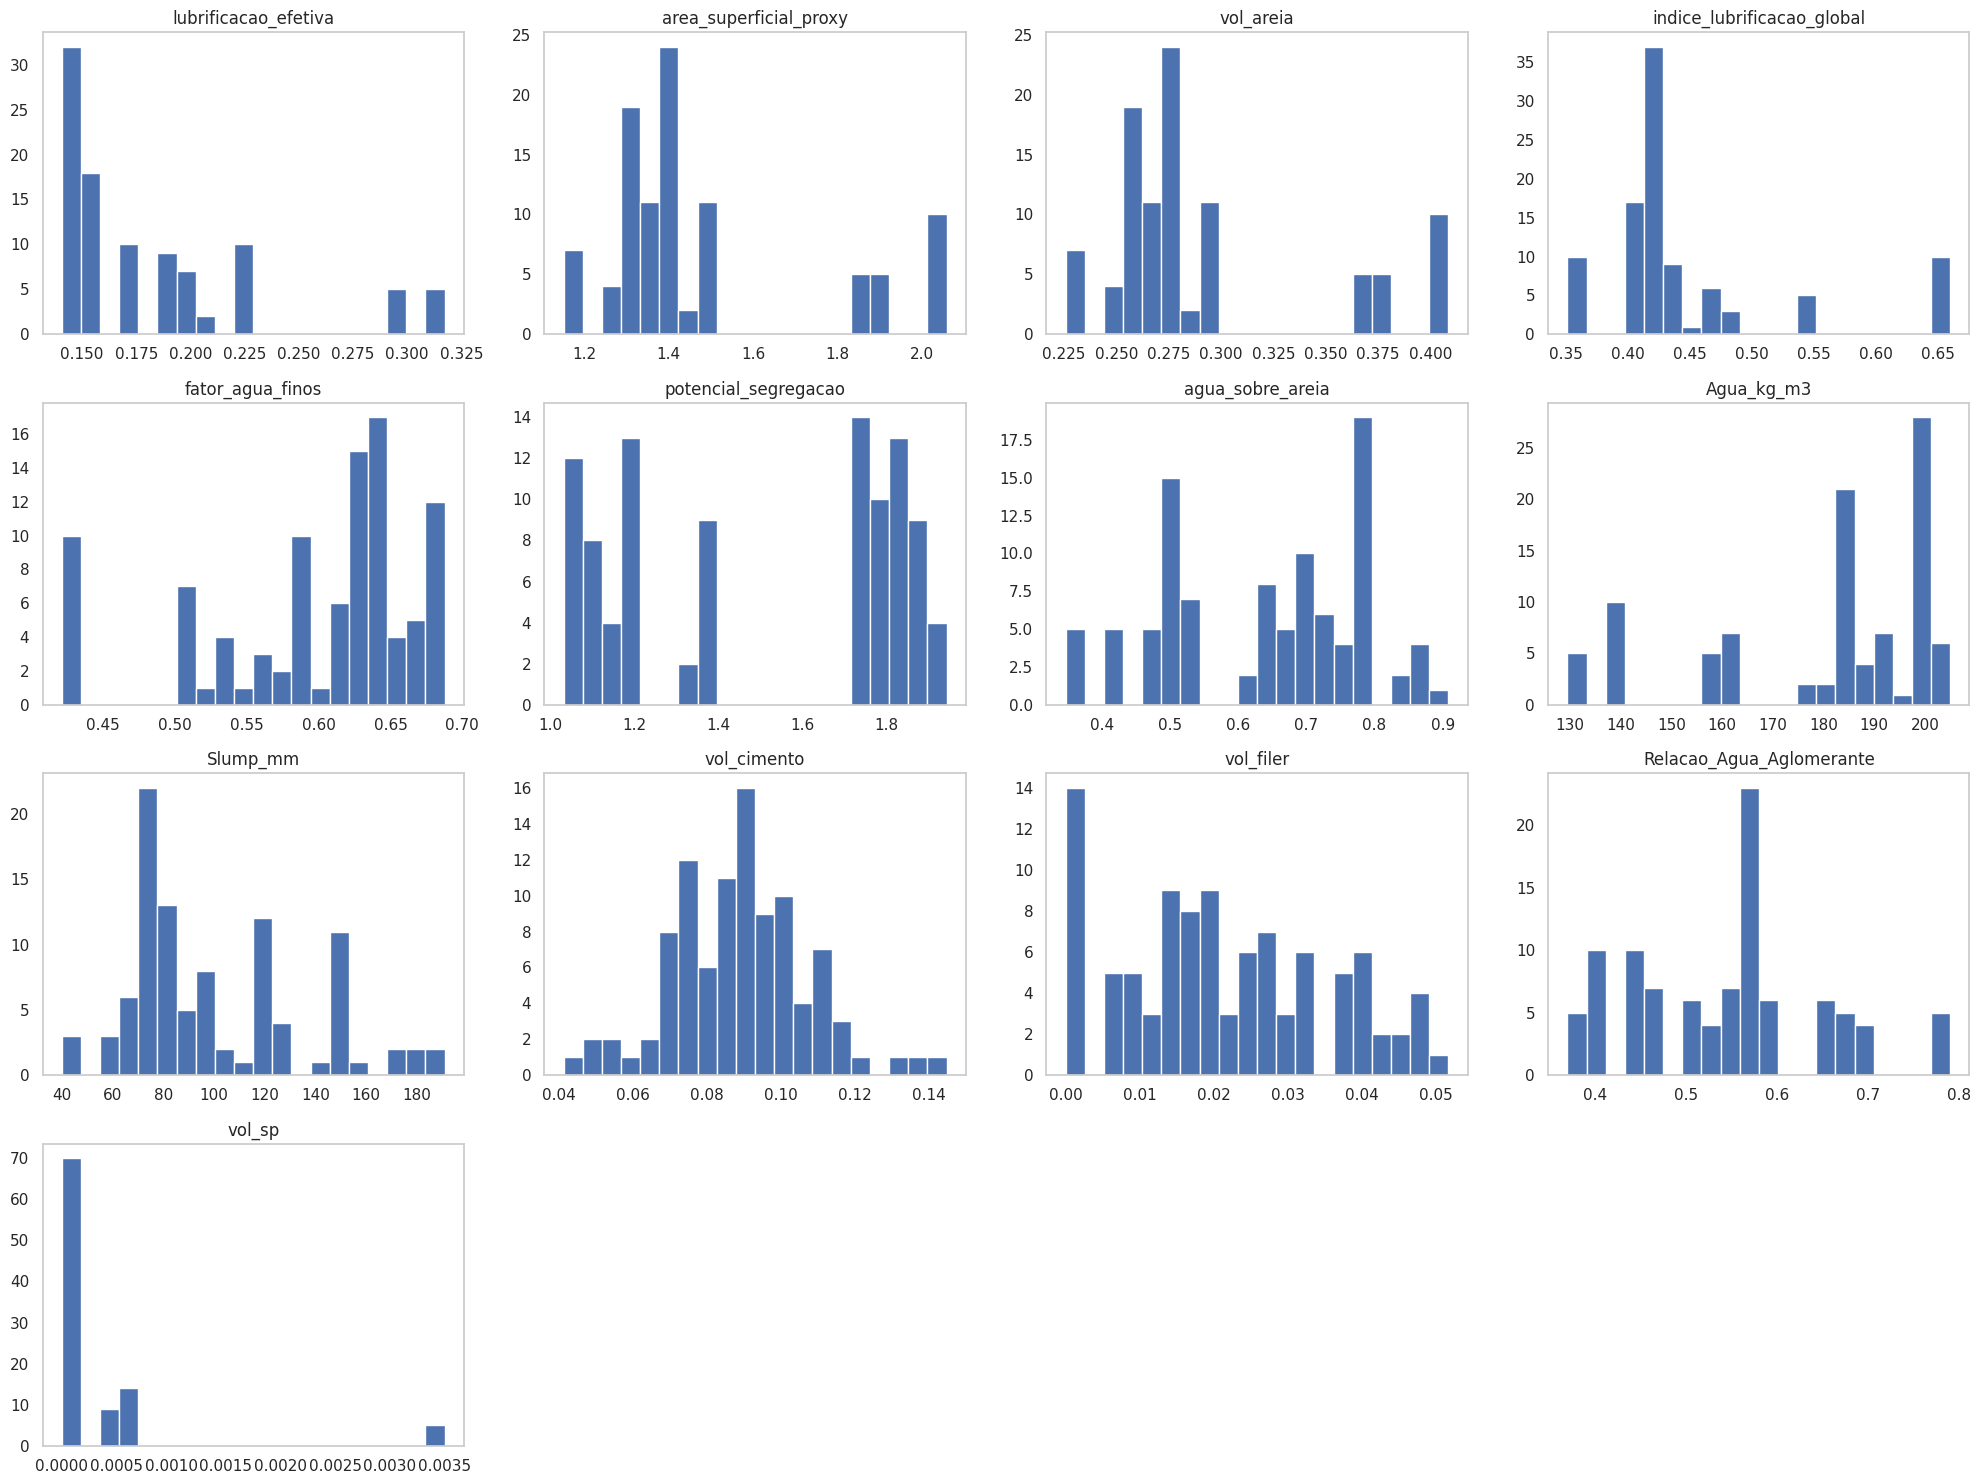

In [442]:
df_final.hist(bins=20, figsize=(20, 15), grid=False)
plt.tight_layout()
plt.show()

In [443]:
df_final.to_pickle(os.path.join(base_dir + "/slump", f'df_slump_{nome_modelo}.pkl'))

In [444]:
# Limites de range das váriaveis numéricas
limites = {}
for column in df_slump.select_dtypes(include=['number']).columns:
    data = df_slump[column]
    lower_bound = data.min()
    upper_bound = data.max()
    limites[column] = (lower_bound, upper_bound)
print("Limites de range das variáveis numéricas:")
for column, (lower, upper) in limites.items():
    print(f"{column}: [{lower:.4f}, {upper:.4f}]")

Limites de range das variáveis numéricas:
Massa_Esp_Cimento_g_cm3: [3.0400, 3.2100]
Finura_Cimento_Blaine_m2_kg: [260.0000, 530.0000]
Massa_Esp_Filer_g_cm3: [2.6900, 2.9200]
Finura_Filer_Blaine_m2_kg: [265.0000, 5980.0000]
Filer_D50_um: [4.4000, 72.0000]
Massa_Esp_Areia_g_cm3: [2.5700, 2.7000]
Massa_Esp_Brita_g_cm3: [2.5100, 2.6500]
D_Max: [9.5000, 30.0000]
Cimento_kg_m3: [129.3000, 487.0000]
Filer_Calcario_kg_m3: [0.0000, 222.5600]
Agua_kg_m3: [129.5000, 205.0000]
Agregado_Miudo_Total_kg_m3: [595.0000, 1170.1700]
Agregado_Graudo_Total_kg_m3: [674.9500, 1249.0000]
Superplastificante_kg_m3: [0.0000, 5.8900]
Superplast_%_cement: [0.0000, 2.2000]
Relacao_Agua_Cimento: [0.3600, 1.4300]
Relacao_Agua_Aglomerante: [0.3400, 0.7900]
Idade_Dias: [1.0000, 28.0000]
Slump_mm: [40.0000, 191.0000]
Densidade_Concreto_Fresco_kg_m3: [2263.0000, 3000.0000]
Resistencia_Compressao_MPa: [1.0000, 52.1400]
Tipo_Molde_Cod: [1.0000, 4.0000]
Classe_Cim_OpA: [32.0000, 63.0000]
Classe_Cim_OpB: [1.0000, 4.0000]
Met